## INTERPRETACIÓN DEL MODELO

### By:
Cristian David Ceballos Velez

### Date:
2026-08-26

### Description:
Interpretación del modelo final (Random Forest) seleccionado en la etapa anterior, para
entender qué variables más influyen en sus predicciones, analizar su comportamiento de
aprendizaje y escalabilidad, y sobre todo **entender los errores que comete** — con el fin de
construir un listado de pruebas y experimentos para la siguiente iteración del proyecto.

Estructura basada en: [Interpretación de Modelo - Jose R. Zapata](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/7-model_interpretation/)

## 📚 1. Importar librerías

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import load
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, recall_score
from sklearn.model_selection import ShuffleSplit, learning_curve, train_test_split

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


## 💾 2. Cargar el modelo entrenado

In [17]:
MODELS_DIR = Path.cwd().resolve().parents[1] / "models"

heart_model = load(MODELS_DIR / "corazon_classification-random_forest-v1.joblib")
heart_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','chest_pain',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categoric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining c

## 💾 3. Cargar datos

In [ ]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

df = pd.read_parquet(
    DATA_DIR / "02_intermediate" / "corazon_type_fixed.parquet", engine="pyarrow"
)

TARGET = "disease"
df[TARGET] = df[TARGET].astype(int)

cols_int_a_float = ["age", "rest_bp", "chol", "max_hr", "ca"]
for col in cols_int_a_float:
    df[col] = df[col].astype("float64")

cols_bool_a_float = ["fbs", "exang"]
for col in cols_bool_a_float:
    df[col] = df[col].astype("float64")

df = df.drop_duplicates()

X_features = df.drop(columns=[TARGET])
Y_target = df[TARGET]

# Usar el MISMO random_state que en 6-interpretation para reproducir el split original
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, stratify=Y_target, random_state=42
)

print("Train:", x_train.shape, "Test:", x_test.shape)

Train: (174, 13) Test: (44, 13)


## 🔍 4. Interpretación del modelo

### 4.1 Feature Importance (MDI - Mean Decrease in Impurity)

Random Forest permite obtener la importancia de cada variable como la disminución media de impureza que aporta en los árboles del ensamble.

In [19]:
features = heart_model.named_steps["preprocessor"].get_feature_names_out()
importances = heart_model.named_steps["model"].feature_importances_

df_features = pd.DataFrame({"Features": features, "Importances": importances})
df_features = df_features.sort_values(by="Importances", ascending=False)
df_features

,Features,Importances
4,numeric__old_peak,0.125673
3,numeric__max_hr,0.124395
8,numeric__exang,0.093761
5,numeric__slope,0.085244
0,numeric__age,0.083722
6,numeric__ca,0.078622
2,numeric__chol,0.073970
1,numeric__rest_bp,0.062970
19,categoric__thal_reversable,0.056085
18,categoric__thal_normal,0.055959


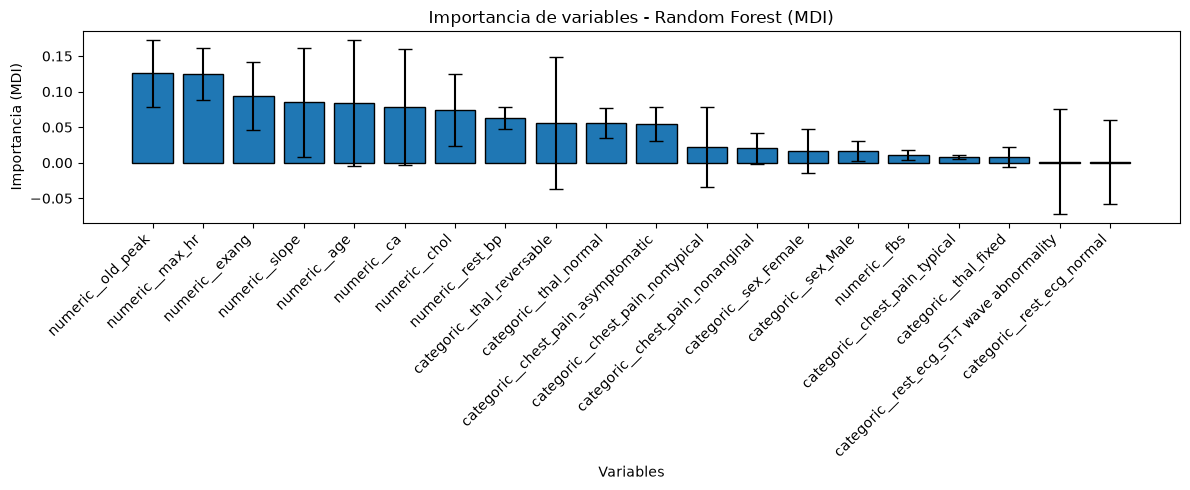

In [ ]:
std = np.std(
    [
        tree.feature_importances_
        for tree in heart_model.named_steps["model"].estimators_
    ],
    axis=0,
)
df_features["std"] = std
df_features = df_features.sort_values(by="Importances", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(
    df_features["Features"],
    df_features["Importances"],
    yerr=df_features["std"],
    capsize=5,
    edgecolor="black",
)
plt.xlabel("Variables")
plt.ylabel("Importancia (MDI)")
plt.title("Importancia de variables - Random Forest (MDI)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.2 Permutation Importance

La importancia MDI puede estar sesgada hacia variables numéricas con muchos valores únicos.
La importancia por permutación es más confiable: mide cuánto empeora el desempeño del modelo
(en Recall, nuestra métrica principal) al mezclar aleatoriamente los valores de cada variable
en el set de test.

/tmp/ipykernel_12249/2926483117.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


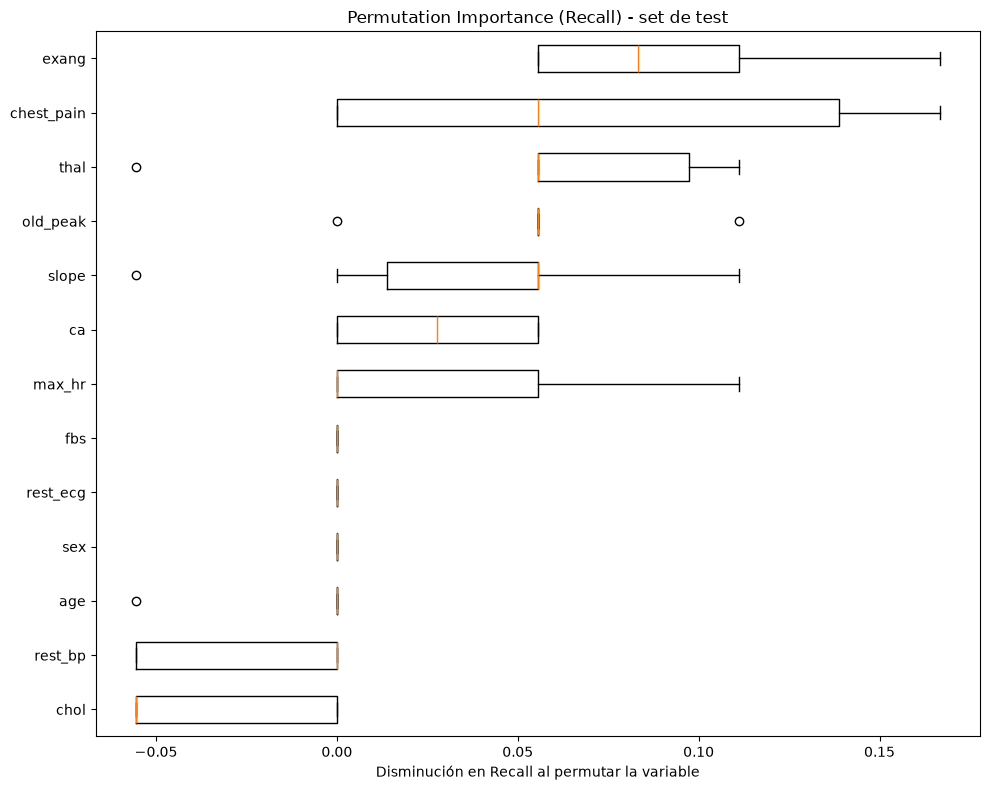

In [ ]:
perm_importance = permutation_importance(
    heart_model,
    x_test,
    y_test,
    scoring="recall",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 8))
plt.boxplot(
    perm_importance.importances[perm_sorted_idx].T,
    vert=False,
    tick_labels=x_test.columns[perm_sorted_idx],
)
plt.title("Permutation Importance (Recall) - set de test")
plt.xlabel("Disminución en Recall al permutar la variable")
plt.tight_layout()
plt.show()

**Comparación MDI vs. Permutation Importance:** revisa si ambas coinciden en las variables más
importantes (esperado, dado el conocimiento clínico previo: `thal`, `ca`, `chest_pain` suelen ser
las más predictivas). Si difieren mucho, puede ser señal de variables numéricas con muchos
valores únicos inflando artificialmente el MDI — documenta el hallazgo aquí.

## 📈 5. Learning Curve

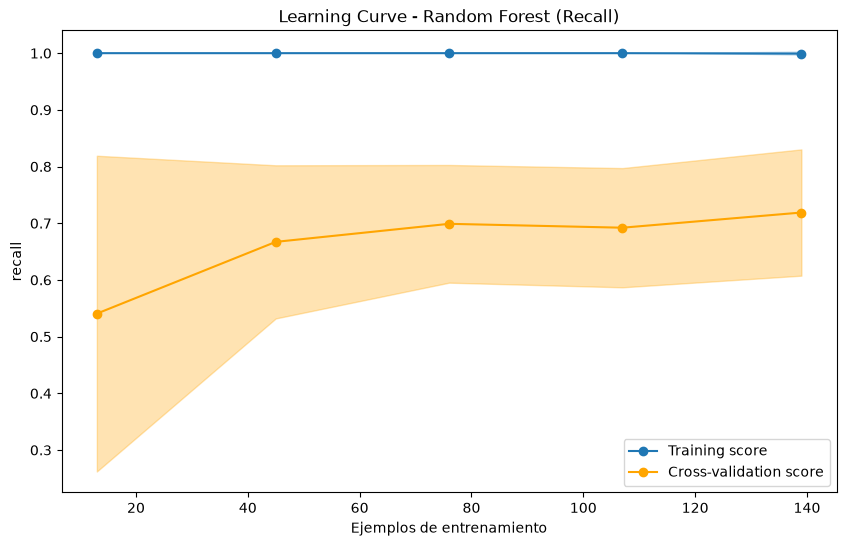

Training Sizes: [ 13  45  76 107 139]
Training Scores Mean: [1.         1.         1.         1.         0.99924528]
Test Scores Mean: [0.54060269 0.66716594 0.69899136 0.69214002 0.71889528]


In [ ]:
common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
}

scoring_metric = "recall"

train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    heart_model, **common_params, scoring=scoring_metric
)

train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
test_mean, test_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)
fit_times_mean, fit_times_std = np.mean(fit_times, axis=1), np.std(fit_times, axis=1)
score_times_mean, score_times_std = (
    np.mean(score_times, axis=1),
    np.std(score_times, axis=1),
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training score")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(
    train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange"
)
ax.set_title("Learning Curve - Random Forest (Recall)")
ax.set_xlabel("Ejemplos de entrenamiento")
ax.set_ylabel(scoring_metric)
ax.legend(loc="best")
plt.show()

print("Training Sizes:", train_sizes)
print("Training Scores Mean:", train_mean)
print("Test Scores Mean:", test_mean)

## ⚙️ 6. Escalabilidad (tiempo de entrenamiento y score)

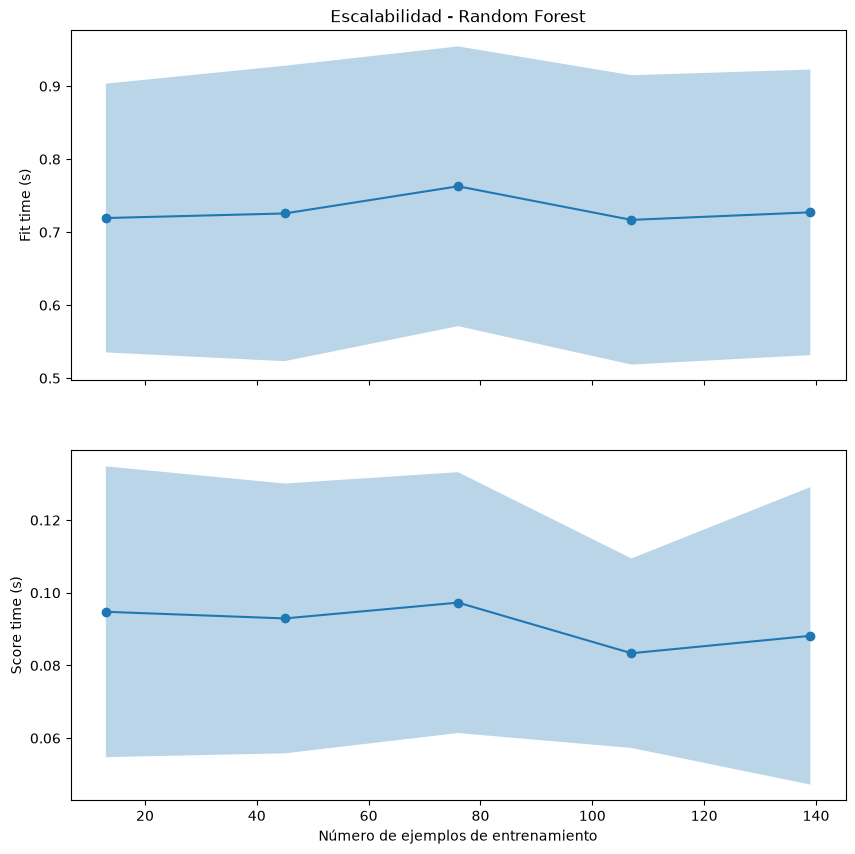

Fit Times Mean: [0.71936409 0.72563616 0.76285503 0.71682616 0.72718442]
Score Times Mean: [0.09477394 0.09294188 0.09729656 0.08336803 0.08815287]


In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

ax[0].plot(train_sizes, fit_times_mean, "o-")
ax[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title("Escalabilidad - Random Forest")

ax[1].plot(train_sizes, score_times_mean, "o-")
ax[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)
ax[1].set_ylabel("Score time (s)")
ax[1].set_xlabel("Número de ejemplos de entrenamiento")

plt.show()

print("Fit Times Mean:", fit_times_mean)
print("Score Times Mean:", score_times_mean)

## ❌ 7. Análisis de errores del modelo

### 7.1 Matriz de confusión y reporte de clasificación

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        26
           1       1.00      0.78      0.88        18

    accuracy                           0.91        44
   macro avg       0.93      0.89      0.90        44
weighted avg       0.92      0.91      0.91        44



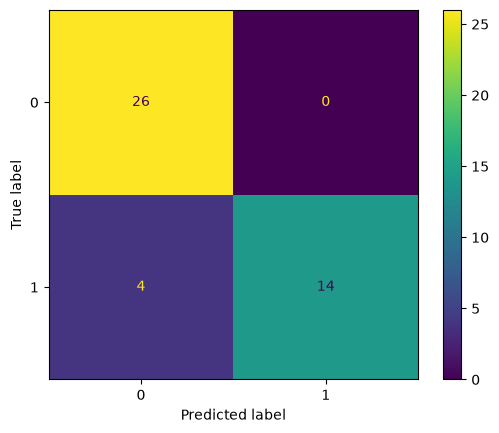

In [24]:
y_pred = heart_model.predict(x_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

### 7.2 ¿Qué tipo de errores comete el modelo?

- **Falsos Negativos (FN)**: pacientes con enfermedad real (`disease=1`) que el modelo predice
  como sanos. **Es el error más costoso en este problema** — un paciente enfermo no recibiría
  seguimiento/tratamiento oportuno.
- **Falsos Positivos (FP)**: pacientes sanos (`disease=0`) que el modelo predice como enfermos.
  Costo menor (exámenes adicionales innecesarios), pero no despreciable.

In [ ]:
x_test_analisis = x_test.copy()
x_test_analisis["y_real"] = y_test.values
x_test_analisis["y_pred"] = y_pred

falsos_negativos = x_test_analisis[
    (x_test_analisis["y_real"] == 1) & (x_test_analisis["y_pred"] == 0)
]
falsos_positivos = x_test_analisis[
    (x_test_analisis["y_real"] == 0) & (x_test_analisis["y_pred"] == 1)
]

print(
    f"Falsos Negativos: {len(falsos_negativos)} de {len(x_test_analisis)} ({len(falsos_negativos) / len(x_test_analisis) * 100:.2f}%)"
)
print(
    f"Falsos Positivos: {len(falsos_positivos)} de {len(x_test_analisis)} ({len(falsos_positivos) / len(x_test_analisis) * 100:.2f}%)"
)

Falsos Negativos: 4 de 44 (9.09%)
Falsos Positivos: 0 de 44 (0.00%)


### 7.3 ¿A qué se deben los errores? — caracterización de los casos mal clasificados

In [ ]:
cols_numeric = [
    "age",
    "rest_bp",
    "chol",
    "max_hr",
    "old_peak",
    "slope",
    "ca",
    "fbs",
    "exang",
]

print(
    "--- Estadísticas de variables numéricas: Falsos Negativos vs. resto del test ---"
)
comparacion_fn = pd.DataFrame(
    {
        "Falsos_Negativos": falsos_negativos[cols_numeric].mean(),
        "Resto_del_test": x_test_analisis[
            ~x_test_analisis.index.isin(falsos_negativos.index)
        ][cols_numeric].mean(),
    }
)
comparacion_fn["Diferencia"] = (
    comparacion_fn["Falsos_Negativos"] - comparacion_fn["Resto_del_test"]
)
comparacion_fn

--- Estadísticas de variables numéricas: Falsos Negativos vs. resto del test ---


,Falsos_Negativos,Resto_del_test,Diferencia
age,53.25,54.051282,-0.801282
rest_bp,137.50,128.393939,9.106061
chol,247.50,237.612903,9.887097
max_hr,167.00,149.324324,17.675676
old_peak,0.25,1.030769,-0.780769
slope,1.50,1.475000,0.025000
ca,0.25,0.564103,-0.314103
fbs,0.00,0.062500,-0.062500
exang,0.00,0.400000,-0.400000


_Interpretación de la tabla anterior:_ si alguna variable numérica muestra una diferencia
grande entre los Falsos Negativos y el resto del test, sugiere que el modelo tiene dificultad
para identificar correctamente pacientes enfermos con valores atípicos/límite en esa variable
(ej. pacientes enfermos con colesterol o presión "normales", que no encajan con el patrón típico
que el modelo aprendió).

In [27]:
cols_categoric = ["sex", "chest_pain", "rest_ecg", "thal"]

print("--- Distribución de variables categóricas en Falsos Negativos ---")
for col in cols_categoric:
    print(f"\n{col}:")
    print(falsos_negativos[col].value_counts(normalize=True).round(3) * 100)

--- Distribución de variables categóricas en Falsos Negativos ---

sex:
sex
Male      100.0
2345        0.0
45          0.0
765         0.0
Female      0.0
Name: proportion, dtype: float64

chest_pain:
chest_pain
asymptomatic    50.0
nonanginal      25.0
nontypical      25.0
2345             0.0
2435             0.0
3456             0.0
typical          0.0
Name: proportion, dtype: float64

rest_ecg:
rest_ecg
normal                           100.0
3563                               0.0
36653                              0.0
435647                             0.0
5653                               0.0
5678                               0.0
ST-T wave abnormality              0.0
left ventricular hypertrophy       0.0
Name: proportion, dtype: float64

thal:
thal
reversable    75.0
normal        25.0
365635463      0.0
53646          0.0
56             0.0
87654          0.0
fixed          0.0
Name: proportion, dtype: float64


### 7.4 ¿Los errores se concentran en valores atípicos (outliers)?

In [ ]:
for col in cols_numeric:
    q1, q3 = x_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    fn_outliers = (
        (falsos_negativos[col] < lim_inf) | (falsos_negativos[col] > lim_sup)
    ).sum()
    if len(falsos_negativos) > 0:
        print(
            f"{col}: {fn_outliers}/{len(falsos_negativos)} Falsos Negativos son outliers "
            f"({fn_outliers / len(falsos_negativos) * 100:.1f}%)"
        )

age: 0/4 Falsos Negativos son outliers (0.0%)
rest_bp: 0/4 Falsos Negativos son outliers (0.0%)
chol: 0/4 Falsos Negativos son outliers (0.0%)
max_hr: 0/4 Falsos Negativos son outliers (0.0%)
old_peak: 0/4 Falsos Negativos son outliers (0.0%)
slope: 0/4 Falsos Negativos son outliers (0.0%)
ca: 0/4 Falsos Negativos son outliers (0.0%)
fbs: 0/4 Falsos Negativos son outliers (0.0%)
exang: 0/4 Falsos Negativos son outliers (0.0%)


### 7.5 ¿Los errores están asociados a datos faltantes que fueron imputados?

In [29]:
nulos_originales = df.loc[falsos_negativos.index].isna().sum()
print("Valores nulos (antes de imputar) en las filas que resultaron Falso Negativo:")
nulos_originales[nulos_originales > 0]

Valores nulos (antes de imputar) en las filas que resultaron Falso Negativo:


Series([], dtype: int64)

### 7.6 ¿Los errores se deben a desbalance de clases?

Aunque el dataset está razonablemente balanceado (~54% / ~46%), revisa si el desempeño difiere
notablemente entre clases (Recall de la clase 1 vs. Precision/Recall de la clase 0 en el
`classification_report` de la sección 7.1). Un desbalance leve normalmente no explica errores
grandes, pero conviene descartarlo explícitamente.

In [ ]:
print("Distribución de clases en train:")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\nDistribución de clases en los Falsos Negativos vs. test completo:")
print(f"% de la clase 1 (enfermos) en test: {(y_test == 1).mean() * 100:.1f}%")
print(
    f"% de Falsos Negativos sobre el total de enfermos reales en test: "
    f"{len(falsos_negativos) / (y_test == 1).sum() * 100:.1f}%"
)

Distribución de clases en train:
disease
0    60.3
1    39.7
Name: proportion, dtype: float64

Distribución de clases en los Falsos Negativos vs. test completo:
% de la clase 1 (enfermos) en test: 40.9%
% de Falsos Negativos sobre el total de enfermos reales en test: 22.2%


### 7.7 ¿Los errores se deben a codificación (encoders) o a la calidad de captura de datos?

Preguntas a resolver manualmente revisando los casos de la sección 7.3:
- ¿Alguna categoría rara (ej. una categoría con muy pocos registros en `chest_pain`, `thal`,
  `rest_ecg`) aparece sobre-representada en los Falsos Negativos? Si es así, el
  `OneHotEncoder(handle_unknown="ignore")` podría no tener suficientes ejemplos de esa categoría
  para aprender su patrón.
- ¿Los datos de los Falsos Negativos muestran combinaciones de valores clínicamente
  inconsistentes (ej. `chest_pain="asymptomatic"` con `old_peak` muy bajo)? Podría indicar
  errores de captura en el dataset original, no necesariamente una limitación del modelo.

## 🩺 8. Consecuencias de las malas predicciones

- **Falso Negativo** (paciente enfermo clasificado como sano): consecuencia potencialmente
  grave — el paciente no recibe seguimiento médico oportuno, con riesgo de progresión de la
  enfermedad sin tratamiento. Es el error prioritario a minimizar (por eso Recall es la métrica
  principal desde la etapa de modelo base).
- **Falso Positivo** (paciente sano clasificado como enfermo): consecuencia menos grave pero con
  costo real — exámenes médicos adicionales innecesarios, ansiedad del paciente, costo para el
  sistema de salud.

Esta asimetría de consecuencias refuerza la decisión de optimizar por Recall en vez de Accuracy
general, tomada desde la etapa de modelo base.

## 📊 9. Análisis de resultados

_Completar con los valores/hallazgos reales obtenidos en las secciones anteriores:_

- **Variables más importantes (MDI):** (completar con el top 3-4 de la sección 4.1)
- **Variables más importantes (Permutation):** (completar con el top 3-4 de la sección 4.2)
  — ¿coinciden con MDI?
- **Comportamiento de la Learning Curve:** ¿el modelo se beneficiaría de más datos, o ya
  convergió con el tamaño actual del dataset?
- **Escalabilidad:** ¿el tiempo de entrenamiento es aceptable para reentrenamientos periódicos
  en producción?
- **Patrón principal de error:** (completar) — con base en las secciones 7.3 a 7.7, ¿los
  Falsos Negativos se concentran en outliers, en una categoría específica, en datos con
  imputación, o no muestran un patrón claro?

## 📝 10. Listado de pruebas y experimentos para la siguiente iteración

_Basado en los hallazgos de este notebook:_

1. **(Completar)** — ej. "Si los Falsos Negativos se concentran en `old_peak` bajo con
   `chest_pain=asymptomatic`, probar agregar una variable de interacción entre ambas."
2. **(Completar)** — ej. "Si el permutation importance muestra que `rest_ecg` casi no aporta,
   evaluar eliminarla para simplificar el modelo (menor riesgo de overfitting)."
3. **(Completar)** — ej. "Si hay evidencia de outliers concentrados en Falsos Negativos, probar
   un `RobustScaler` en vez de `StandardScaler` para las variables numéricas."
4. **(Completar)** — ej. "Ajustar el umbral de decisión del modelo (por debajo de 0.5) para
   priorizar aún más el Recall, y medir el costo en Precision."
5. **(Completar)** — ej. "Si la Learning Curve no se estabilizó, priorizar conseguir más datos
   etiquetados sobre seguir ajustando hiperparámetros.

## 🧑‍🔬 11. Recomendaciones

1. **No usar el modelo en producción sin ajuste de umbral**: dado el costo alto de los Falsos
   Negativos, evaluar si mover el umbral de decisión reduce el Recall perdido, aunque implique
   más Falsos Positivos.
2. **Monitorear las variables más importantes en producción**: priorizar la calidad de captura
   de `thal`, `ca`, `chest_pain` (o las que resulten más importantes en tus resultados reales),
   ya que errores de captura ahí tienen mayor impacto en las predicciones.
3. **Revisar manualmente los casos de Falso Negativo con el equipo clínico**, si es posible,
   para validar si el patrón encontrado en la sección 7 tiene sentido médico o es una limitación
   puramente estadística del modelo.